## Week 7 — Model Explainability: SHAP & LIME

This notebook explores **why** the LightGBM model makes its predictions using two complementary explainability techniques:

- **SHAP** (SHapley Additive exPlanations): measures the global contribution of each feature across all predictions
- **LIME** (Local Interpretable Model-agnostic Explanations): explains individual predictions by identifying the most influential words



In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from src.preprocess import load_and_prepare
from src.predict import FakeNewsPredictor

## 1. Load Model & Data

In [2]:
predictor = FakeNewsPredictor(data_dir='../data')
X_train, X_test, y_train, y_test, tfidf, feature_cols, subject_enc, df = load_and_prepare(
    data_dir='../data',
    test_size=0.2,
    random_state=42,
    include_subject=False
)
print("Model and data loaded ✅")

Model and data loaded ✅


## 2. Install Dependencies


In [3]:
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "shap", "lime"], capture_output=True)
print("Done!")

Done!


In [4]:
import shap

X_sample = X_test[:200]

explainer = shap.TreeExplainer(predictor._model)
shap_values = explainer.shap_values(X_sample)

print("SHAP values computed ✅")
print(f"Shape: {shap_values.shape}")

c:\Users\loulouu\OneDrive\Bureau\fake_news_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values computed ✅
Shape: (200, 50007)


c:\Users\loulouu\OneDrive\Bureau\fake_news_project\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## 3. SHAP — Global Feature Importance

We use `TreeExplainer` which is optimized for tree-based models like LightGBM.  
We compute SHAP values on a sample of 200 test articles, then plot the **top 20 most influential features** across all predictions.


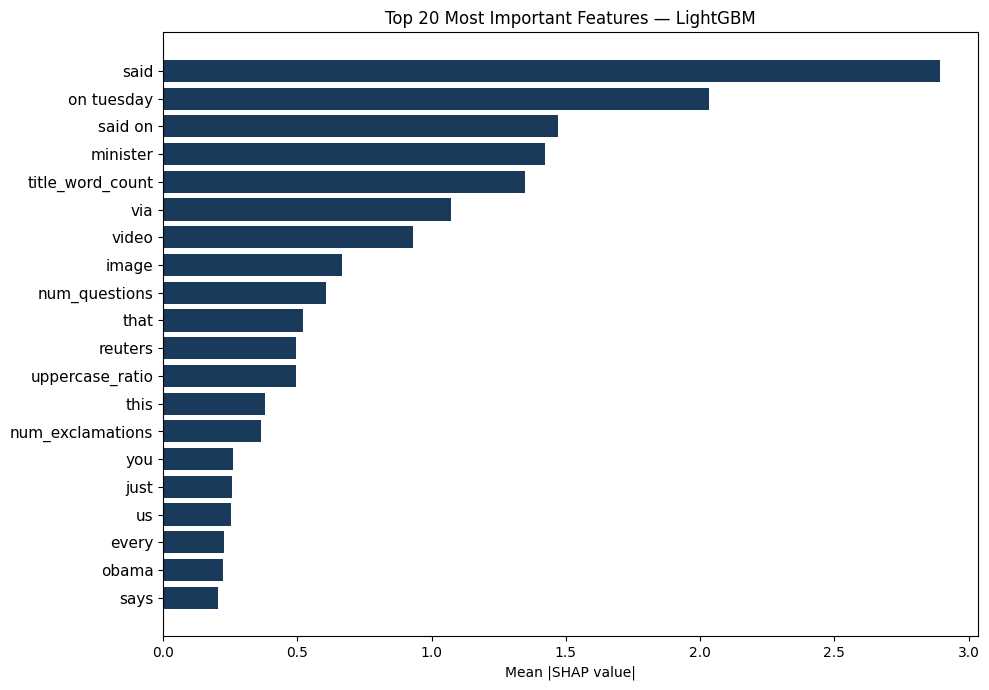

Saved ✅


In [5]:
import matplotlib.pyplot as plt
import numpy as np

tfidf_names = tfidf.get_feature_names_out().tolist()
feature_names = tfidf_names + feature_cols

shap_vals = np.array(shap_values[1])

mean_shap = np.abs(shap_vals).mean(axis=0)
mean_shap = np.asarray(mean_shap).flatten()
top20_idx = np.argsort(mean_shap)[-20:][::-1]
top20_idx = [int(i) for i in top20_idx]
top20_names = [feature_names[i] for i in top20_idx]
top20_vals = mean_shap[top20_idx]

plt.figure(figsize=(10, 7))
plt.barh(range(20), top20_vals[::-1], color="#1a3a5c")
plt.yticks(range(20), top20_names[::-1], fontsize=11)
plt.xlabel("Mean |SHAP value|")
plt.title("Top 20 Most Important Features — LightGBM")
plt.tight_layout()
plt.savefig("../data/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ✅")

## 4. LIME — Local Explanation on a Real Article

LIME perturbs the input text by randomly masking words and observes how the prediction changes.  
Words with **positive weight** push the prediction toward REAL, **negative weight** toward FAKE.

c:\Users\loulouu\OneDrive\Bureau\fake_news_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


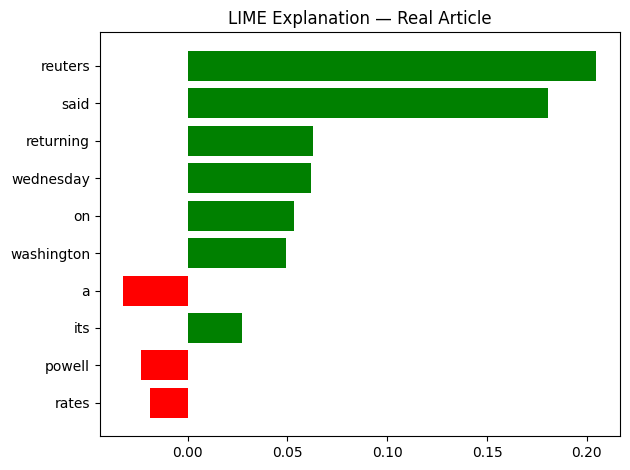

Done ✅


In [6]:
from lime.lime_text import LimeTextExplainer
import numpy as np
from scipy.sparse import hstack, csr_matrix
from src.preprocess import clean_text, extract_features_single

# Article test
test_title = "Federal Reserve raises interest rates by 0.25 percent"
test_text = "WASHINGTON (Reuters) - The Federal Reserve raised its benchmark interest rate by a quarter of a percentage point on Wednesday. Fed Chair Jerome Powell said the committee remains committed to returning inflation to its 2 percent target."

def predict_proba_fn(texts):
    results = []
    for t in texts:
        X_tfidf = predictor._tfidf.transform([t])
        meta = extract_features_single(test_title, t, predictor._feature_cols, None, predictor._subject_enc)
        X_meta = csr_matrix(np.array(meta, dtype=np.float32).reshape(1, -1))
        X = hstack([X_tfidf, X_meta])
        proba = predictor._model.predict_proba(X)[0]
        results.append(proba)
    return np.array(results)

explainer = LimeTextExplainer(class_names=["FAKE", "REAL"])
combined = clean_text(test_title) + " " + clean_text(test_text)
exp = explainer.explain_instance(combined, predict_proba_fn, num_features=10, num_samples=500)

exp.as_pyplot_figure()
plt.title("LIME Explanation — Real Article")
plt.tight_layout()
plt.savefig("../data/lime_real.png", dpi=150, bbox_inches="tight")
plt.show()
print("Done ✅")

## 5. LIME — Local Explanation on a Fake Article

We apply the same LIME approach to a fake article to see which words the model associates with misinformation.

c:\Users\loulouu\OneDrive\Bureau\fake_news_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


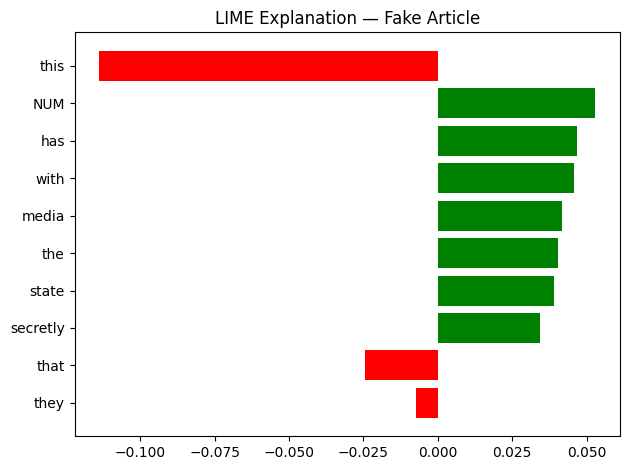

Done ✅


In [7]:
# Article fake
fake_title = "SHOCKING!!! Deep State EXPOSED: Government puts CHIPS in vaccines!!!"
fake_text = "WAKE UP SHEEPLE!!! A whistleblower has come forward with BOMBSHELL evidence that the deep state globalists have been secretly injecting microchips into vaccines since 2020!!! The mainstream media REFUSES to cover this because they are CONTROLLED!!!"

def predict_proba_fake(texts):
    results = []
    for t in texts:
        X_tfidf = predictor._tfidf.transform([t])
        meta = extract_features_single(fake_title, t, predictor._feature_cols, None, predictor._subject_enc)
        X_meta = csr_matrix(np.array(meta, dtype=np.float32).reshape(1, -1))
        X = hstack([X_tfidf, X_meta])
        proba = predictor._model.predict_proba(X)[0]
        results.append(proba)
    return np.array(results)

combined_fake = clean_text(fake_title) + " " + clean_text(fake_text)
exp_fake = explainer.explain_instance(combined_fake, predict_proba_fake, num_features=10, num_samples=500)

exp_fake.as_pyplot_figure()
plt.title("LIME Explanation — Fake Article")
plt.tight_layout()
plt.savefig("../data/lime_fake.png", dpi=150, bbox_inches="tight")
plt.show()
print("Done ✅")

## 6. Summary

Key takeaways from this explainability analysis:
- SHAP reveals that **journalistic vocabulary** (reuters, reported, said) are the strongest signals for REAL articles
- LIME confirms locally that **sensationalist language** (exposed, secretly, agenda) drives FAKE predictions
- The `title_word_count` handcrafted feature appears in the top SHAP features, validating our feature engineering choices

In [8]:
print("=" * 50)
print("EXPLAINABILITY SUMMARY")
print("=" * 50)
print(f"\n✅ SHAP: Top 20 features saved → data/shap_summary.png")
print(f"✅ LIME Real article → data/lime_real.png")
print(f"✅ LIME Fake article → data/lime_fake.png")
print("\nTop 5 most important SHAP features:")
for i, idx in enumerate(top20_idx[:5]):
    print(f"  {i+1}. '{feature_names[idx]}' — {mean_shap[idx]:.4f}")

EXPLAINABILITY SUMMARY

✅ SHAP: Top 20 features saved → data/shap_summary.png
✅ LIME Real article → data/lime_real.png
✅ LIME Fake article → data/lime_fake.png

Top 5 most important SHAP features:
  1. 'said' — 2.8923
  2. 'on tuesday' — 2.0332
  3. 'said on' — 1.4723
  4. 'minister' — 1.4218
  5. 'title_word_count' — 1.3487
